
# Renewable Energy EDA & Forecasting — Clean Restructured Notebook

**Author:** _Your Name_  
**Last Updated:** 2025-09-04 13:07

This notebook restructures and improves the original analysis with a clear flow:
1) Setup & Loading → 2) Cleaning → 3) EDA → 4) Insights → 5) Forecasting → 6) Conclusions.

> Dataset expected at: `Dataset en.csv`


## 1. Setup & Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Statsmodels for time series
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Settings
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
path = "Dataset en.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
display(df.head())
display(df.tail())
print("\nInfo:")
display(df.info())
print("\nMissing values per column:")
display(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (3065, 17)


,Year,Month,Sector,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
0,1973,1,Commerical,0.000,0.000,0.000,0.000,0.570,0.000,0.000,0.000,0.570,0.570,0.000,0.000,0.000,0.000
1,1973,1,Electric Power,0.000,0.490,0.000,0.000,0.054,0.157,0.000,0.000,0.211,89.223,0.000,0.000,88.522,0.000
2,1973,1,Industrial,1.040,0.000,0.000,0.000,98.933,0.000,0.000,0.000,98.933,99.973,0.000,0.000,0.000,0.000
3,1973,1,Residential,0.000,0.000,0.000,0.000,30.074,0.000,0.000,0.000,0.000,30.074,0.000,0.000,0.000,0.000
4,1973,1,Transportation,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


,Year,Month,Sector,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
3060,2024,1,Commerical,0.073,1.669,4.267,0.036,7.053,6.233,2.441,0.000,15.728,21.773,0.000,0.000,0.000,0.000
3061,2024,1,Electric Power,0.000,4.667,32.707,119.265,15.071,13.873,0.000,0.000,28.944,257.661,0.000,0.000,72.078,0.000
3062,2024,1,Industrial,0.308,0.356,0.987,0.035,104.878,14.171,1.533,67.742,188.325,190.011,0.000,0.000,0.000,0.000
3063,2024,1,Residential,0.000,3.354,14.897,0.000,34.065,0.000,0.000,0.000,0.000,52.316,0.000,0.000,0.000,0.000
3064,2024,1,Transportation,0.000,0.000,0.000,0.000,0.000,0.000,86.098,0.000,140.188,0.000,30.780,3.442,0.000,19.867



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3065 entries, 0 to 3064
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Year                                3065 non-null   int64  
 1   Month                               3065 non-null   int64  
 2   Sector                              3065 non-null   object 
 3   Hydroelectric Power                 3065 non-null   float64
 4   Geothermal Energy                   3065 non-null   float64
 5   Solar Energy                        3065 non-null   float64
 6   Wind Energy                         3065 non-null   float64
 7   Wood Energy                         3065 non-null   float64
 8   Waste Energy                        3065 non-null   float64
 9   Fuel Ethanol, Excluding Denaturant  3065 non-null   float64
 10  Biomass Losses and Co-products      3065 non-null   float64
 11  Biomass Energy                      

None


Missing values per column:


Year                                  0
Month                                 0
Sector                                0
Hydroelectric Power                   0
Geothermal Energy                     0
Solar Energy                          0
Wind Energy                           0
Wood Energy                           0
Waste Energy                          0
Fuel Ethanol, Excluding Denaturant    0
Biomass Losses and Co-products        0
Biomass Energy                        0
Total Renewable Energy                0
Renewable Diesel Fuel                 0
Other Biofuels                        0
Conventional Hydroelectric Power      0
Biodiesel                             0
dtype: int64


Duplicate rows: 0


## 2. Data Cleaning

In [2]:

# Remove exact duplicates if any
before = df.shape[0]
df = df.drop_duplicates().copy()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. Current rows: {after}")

# Ensure correct dtypes
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Create a proper Date column (YYYY-MM-01) and sort
if 'Year' in df.columns and 'Month' in df.columns:
    df['Date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
    df = df.sort_values(['Date','Sector']).reset_index(drop=True)

# Basic sanity checks for negatives (energy should not be negative)
neg_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
print("\nNegative values per numeric column:")
display(neg_counts[neg_counts > 0])

# If Total Renewable Energy should be the sum of components, compute and compare
component_cols = [c for c in df.columns if c not in ['Year','Month','Sector','Date','Total Renewable Energy']]
df['Components_Sum'] = df[component_cols].sum(axis=1)

if 'Total Renewable Energy' in df.columns:
    diff = (df['Total Renewable Energy'] - df['Components_Sum']).abs()
    print("\nRows where |Total - sum(components)| > 1e-6:", (diff > 1e-6).sum())


Removed 0 duplicate rows. Current rows: 3065
Numeric columns: ['Year', 'Month', 'Hydroelectric Power', 'Geothermal Energy', 'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy', 'Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products', 'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel', 'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel']
Categorical columns: ['Sector']

Negative values per numeric column:


Hydroelectric Power    1
dtype: int64


Rows where |Total - sum(components)| > 1e-6: 2489


## 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis

,count,mean,std,min,25%,50%,75%,max
Total Renewable Energy,"3,065.000",70.872,71.198,0.000,2.070,50.984,126.982,308.175
Hydroelectric Power,"3,065.000",0.170,0.374,-0.002,0.000,0.000,0.036,2.047
Geothermal Energy,"3,065.000",1.146,1.551,0.000,0.000,0.357,1.673,5.951
Solar Energy,"3,065.000",2.015,5.775,0.000,0.000,0.004,0.774,64.040
Wind Energy,"3,065.000",4.282,18.125,0.000,0.000,0.000,0.001,157.409
Wood Energy,"3,065.000",36.644,46.901,0.000,0.483,12.062,51.808,183.628
Waste Energy,"3,065.000",5.820,8.247,0.000,0.000,0.108,12.764,32.875
"Fuel Ethanol, Excluding Denaturant","3,065.000",6.977,21.912,0.000,0.000,0.007,1.283,104.420
Biomass Losses and Co-products,"3,065.000",4.835,15.602,0.000,0.000,0.000,0.000,75.373
Biomass Energy,"3,065.000",46.286,64.242,0.000,0.258,9.716,89.359,233.200


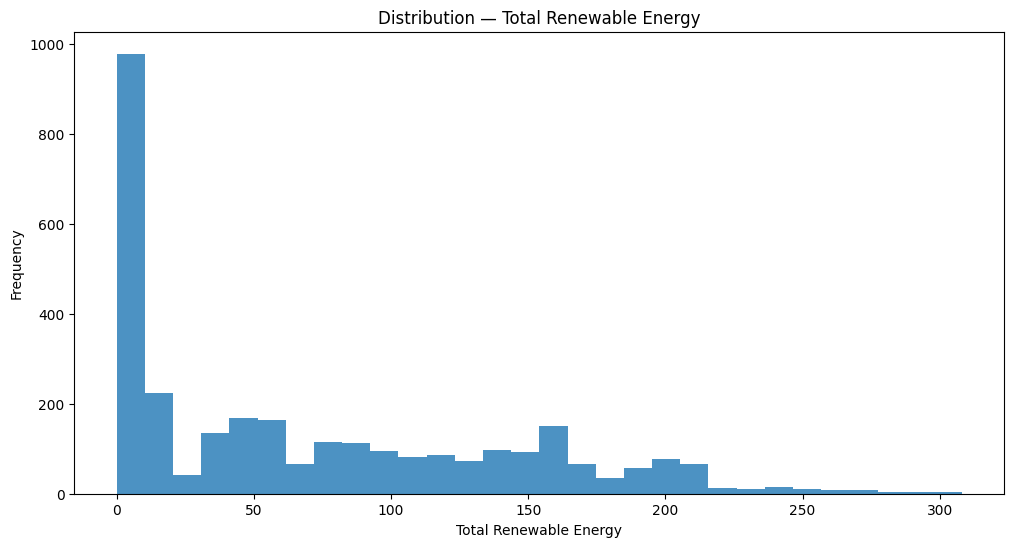

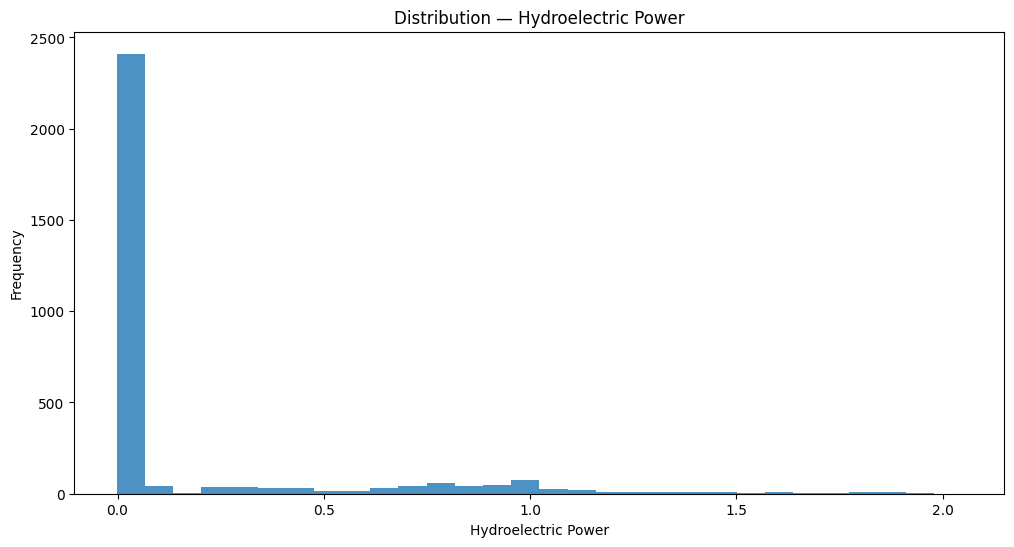

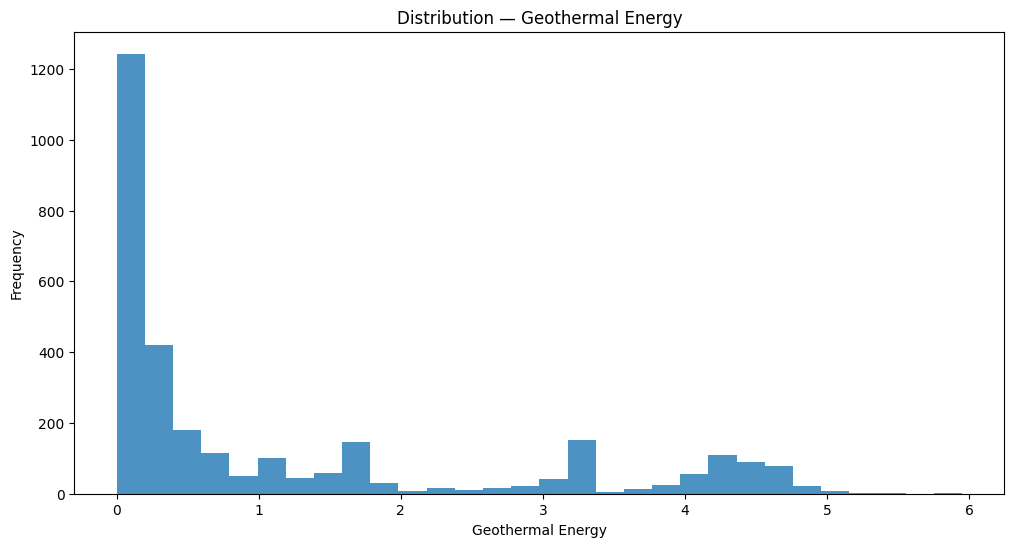

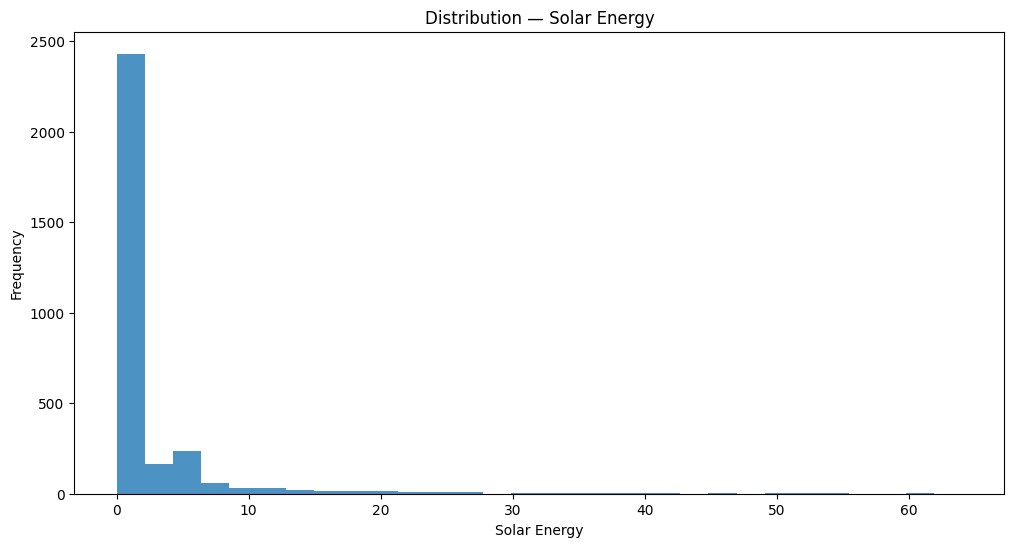

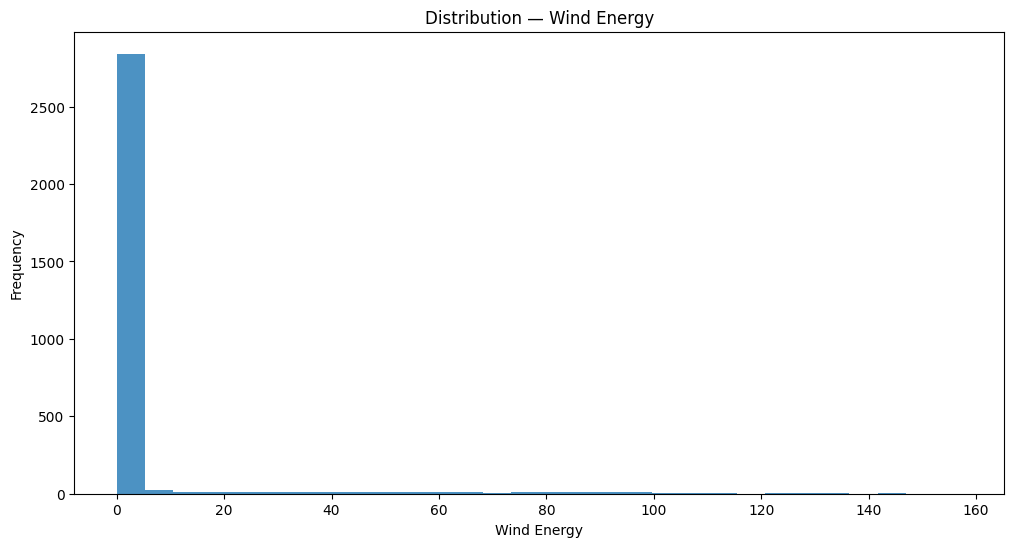

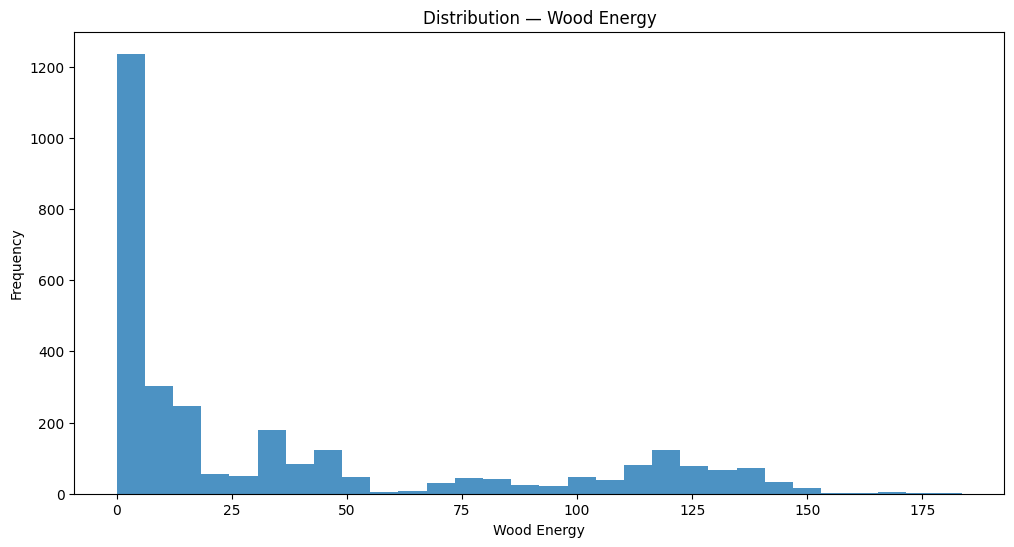

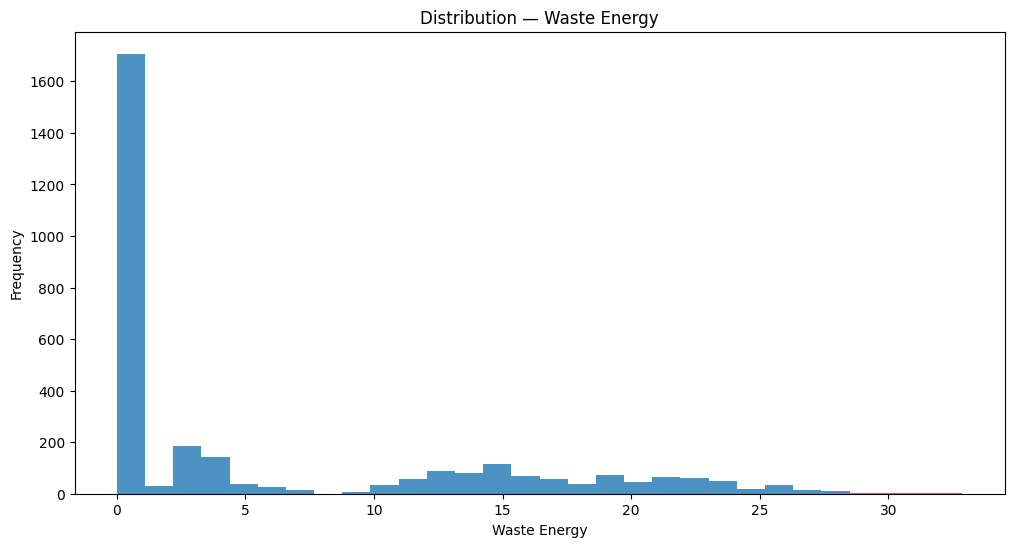

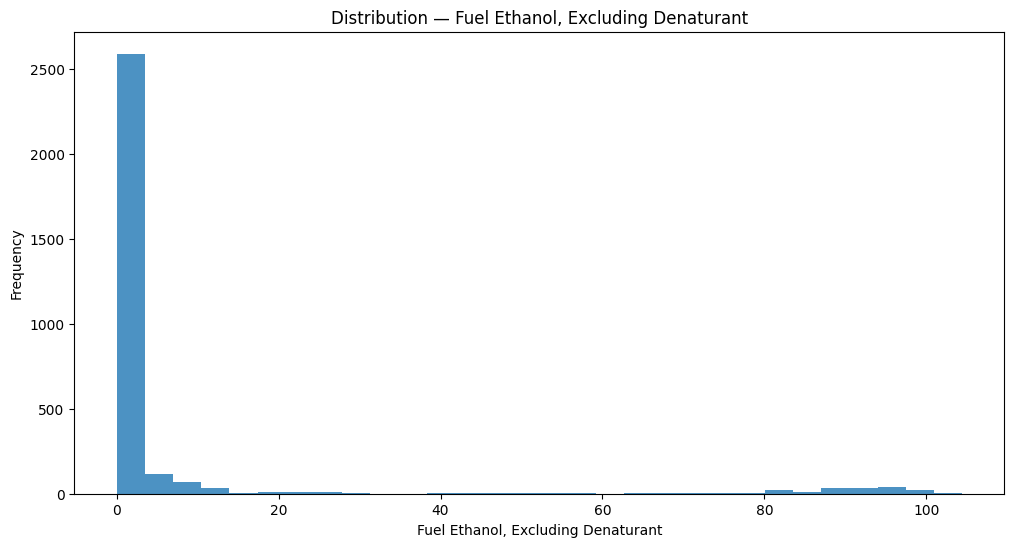

<Figure size 1200x600 with 0 Axes>

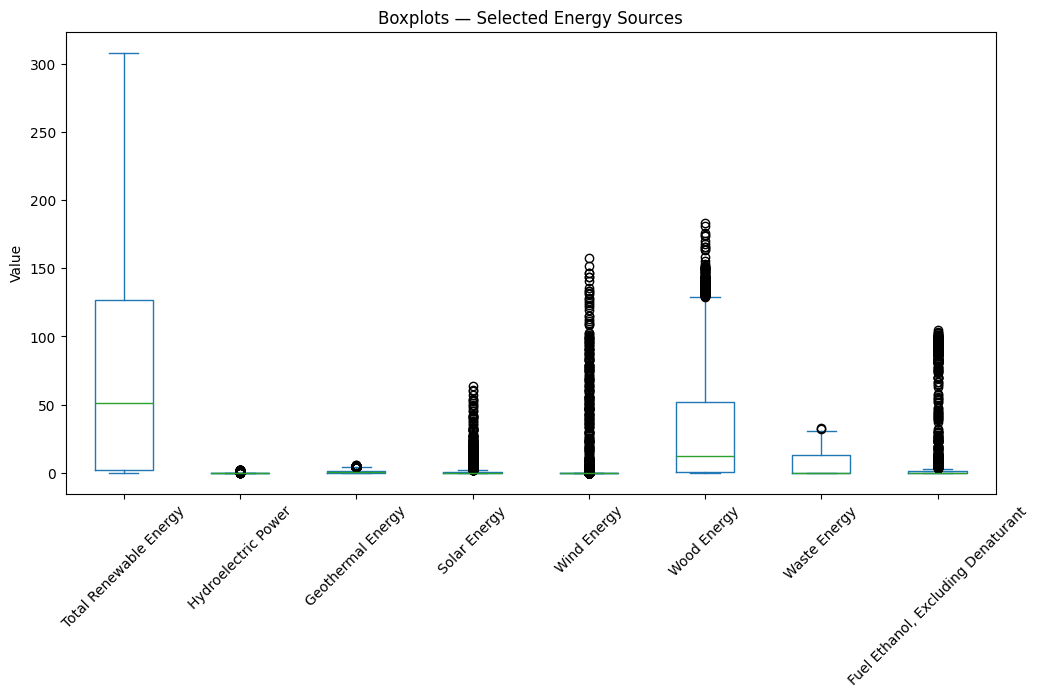

In [3]:

# Summary statistics for key columns
key_cols = ['Total Renewable Energy']
major_sources = [c for c in component_cols if any(k in c.lower() for k in ['solar','wind','hydro','wood','biomass','geothermal','waste','diesel','biodiesel','ethanol'])]
key_cols += major_sources
key_cols = list(dict.fromkeys(key_cols))  # unique & keep order

display(df[key_cols].describe().T)

# Distributions (histograms) for major sources
for col in key_cols[:8]:  # first 8 to keep concise
    plt.figure()
    df[col].plot(kind='hist', bins=30, alpha=0.8)
    plt.title(f"Distribution — {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Boxplots for outliers (subset for readability)
plt.figure()
df[key_cols[:8]].plot(kind='box')
plt.title("Boxplots — Selected Energy Sources")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()


### 3.2 Sector Contribution & Correlation

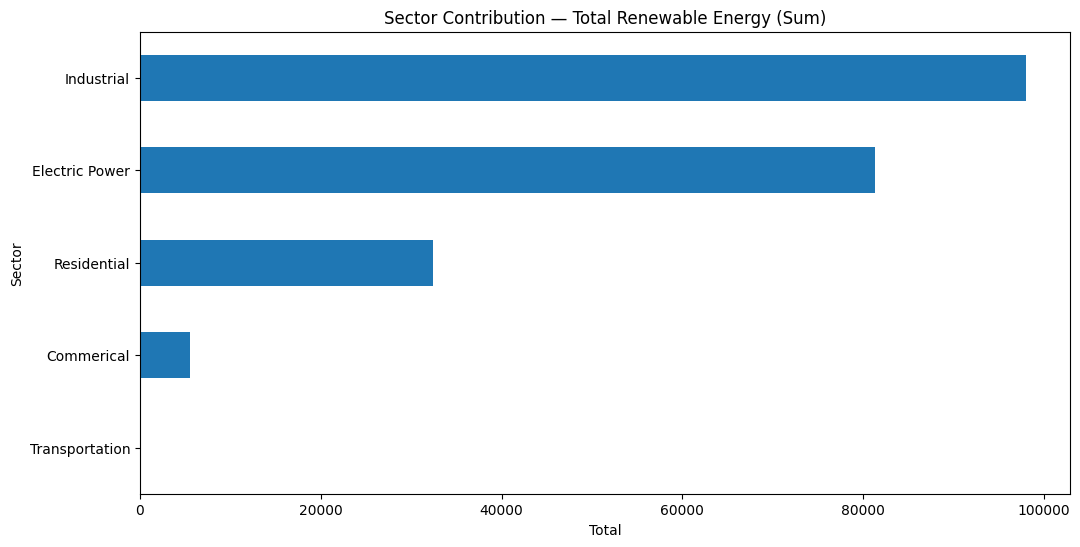

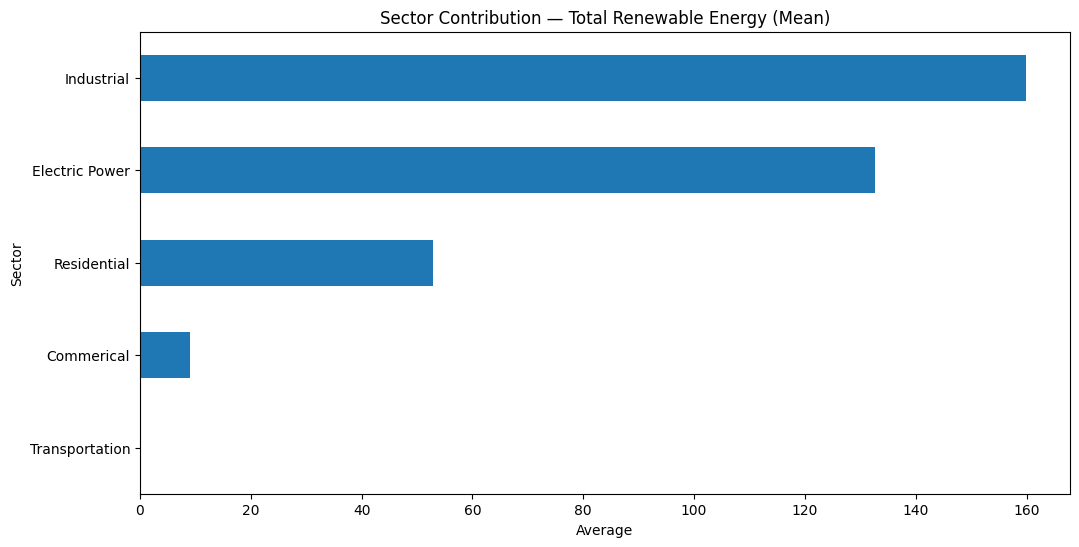

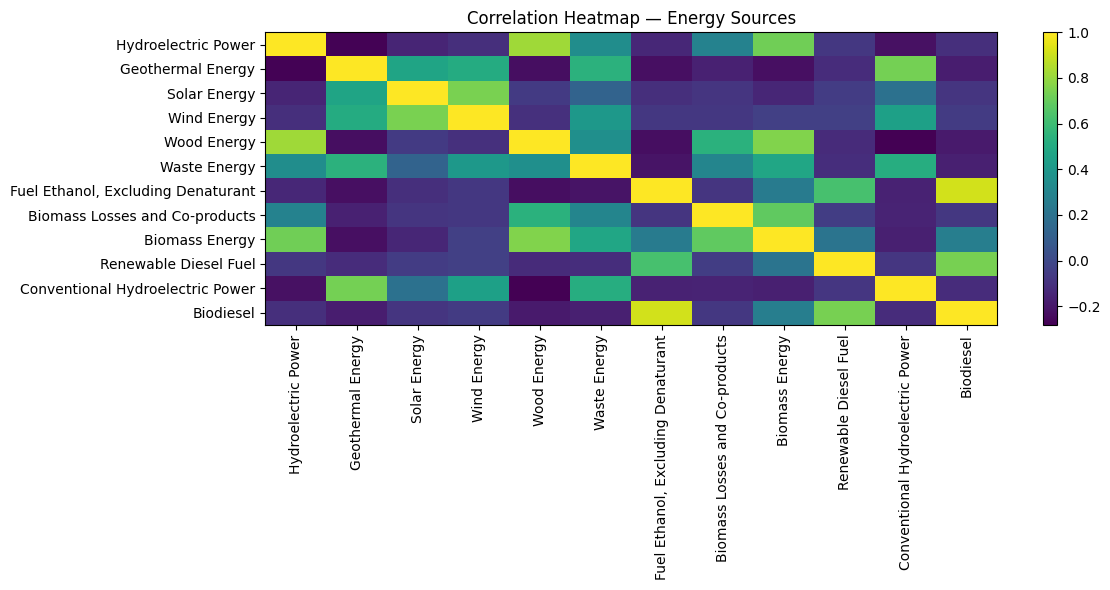

In [4]:

# Sector contribution (mean & sum)
sector_agg_sum = df.groupby('Sector')['Total Renewable Energy'].sum().sort_values(ascending=False)
sector_agg_mean = df.groupby('Sector')['Total Renewable Energy'].mean().sort_values(ascending=False)

# Horizontal bar charts
plt.figure()
sector_agg_sum.plot(kind='barh')
plt.title("Sector Contribution — Total Renewable Energy (Sum)")
plt.xlabel("Total")
plt.gca().invert_yaxis()
plt.show()

plt.figure()
sector_agg_mean.plot(kind='barh')
plt.title("Sector Contribution — Total Renewable Energy (Mean)")
plt.xlabel("Average")
plt.gca().invert_yaxis()
plt.show()

# Correlation among energy sources (excluding totals/identifiers)
corr_cols = major_sources
corr = df[corr_cols].corr()
plt.figure()
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation Heatmap — Energy Sources")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.tight_layout()
plt.show()


### 3.3 Time-Series Trends

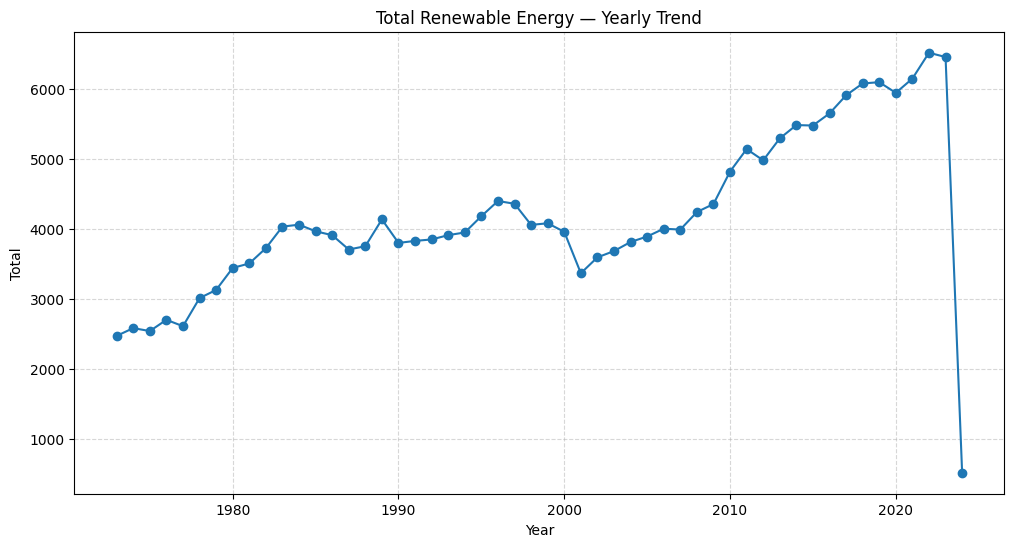

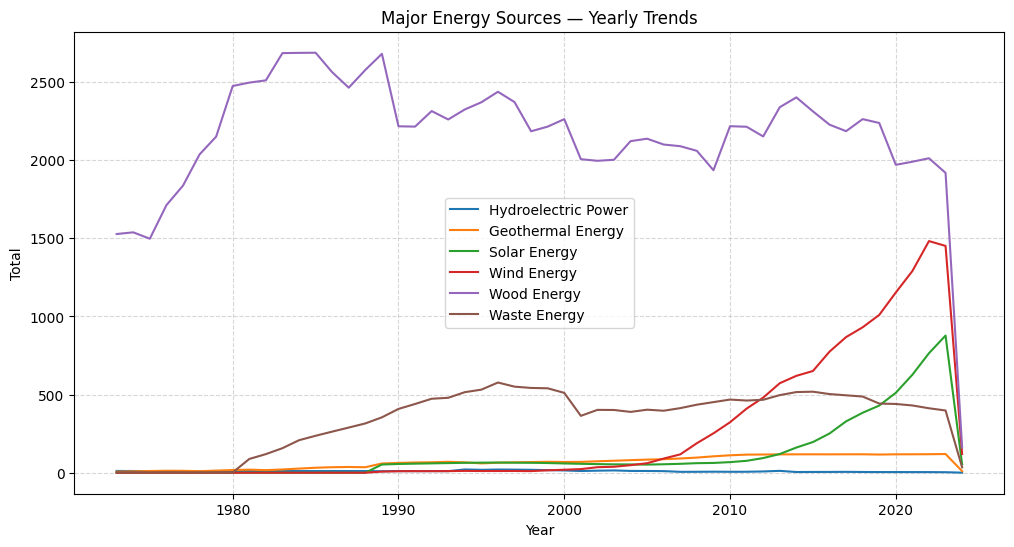

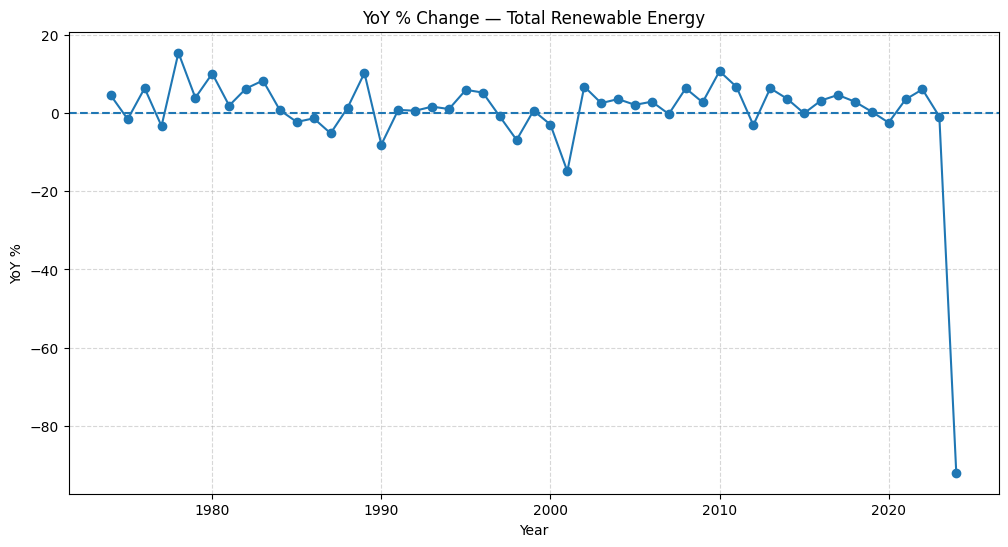

In [5]:

# Yearly totals
yearly_total = df.groupby('Year')['Total Renewable Energy'].sum().reset_index()

plt.figure()
plt.plot(yearly_total['Year'], yearly_total['Total Renewable Energy'], marker='o')
plt.title("Total Renewable Energy — Yearly Trend")
plt.xlabel("Year")
plt.ylabel("Total")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Yearly trends for major sources
yearly_sources = df.groupby('Year')[major_sources].sum().reset_index()

plt.figure()
for col in major_sources[:6]:  # first 6 to keep readable
    plt.plot(yearly_sources['Year'], yearly_sources[col], label=col)
plt.title("Major Energy Sources — Yearly Trends")
plt.xlabel("Year")
plt.ylabel("Total")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# YoY % change for total
yearly_total['YoY %'] = yearly_total['Total Renewable Energy'].pct_change() * 100
plt.figure()
plt.plot(yearly_total['Year'], yearly_total['YoY %'], marker='o')
plt.axhline(0, linestyle='--')
plt.title("YoY % Change — Total Renewable Energy")
plt.xlabel("Year")
plt.ylabel("YoY %")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### 3.4 Insights

Peak year per source: {'Hydroelectric Power': 1994, 'Geothermal Energy': 2023, 'Solar Energy': 2023, 'Wind Energy': 2022, 'Wood Energy': 1985, 'Waste Energy': 1996, 'Fuel Ethanol, Excluding Denaturant': 2019, 'Biomass Losses and Co-products': 2018, 'Biomass Energy': 2016, 'Renewable Diesel Fuel': 2023, 'Conventional Hydroelectric Power': 1997, 'Biodiesel': 2016}
Trough year per source: {'Hydroelectric Power': 2024, 'Geothermal Energy': 1973, 'Solar Energy': 1973, 'Wind Energy': 1973, 'Wood Energy': 2024, 'Waste Energy': 1978, 'Fuel Ethanol, Excluding Denaturant': 1973, 'Biomass Losses and Co-products': 1973, 'Biomass Energy': 2024, 'Renewable Diesel Fuel': 1973, 'Conventional Hydroelectric Power': 2024, 'Biodiesel': 1973}


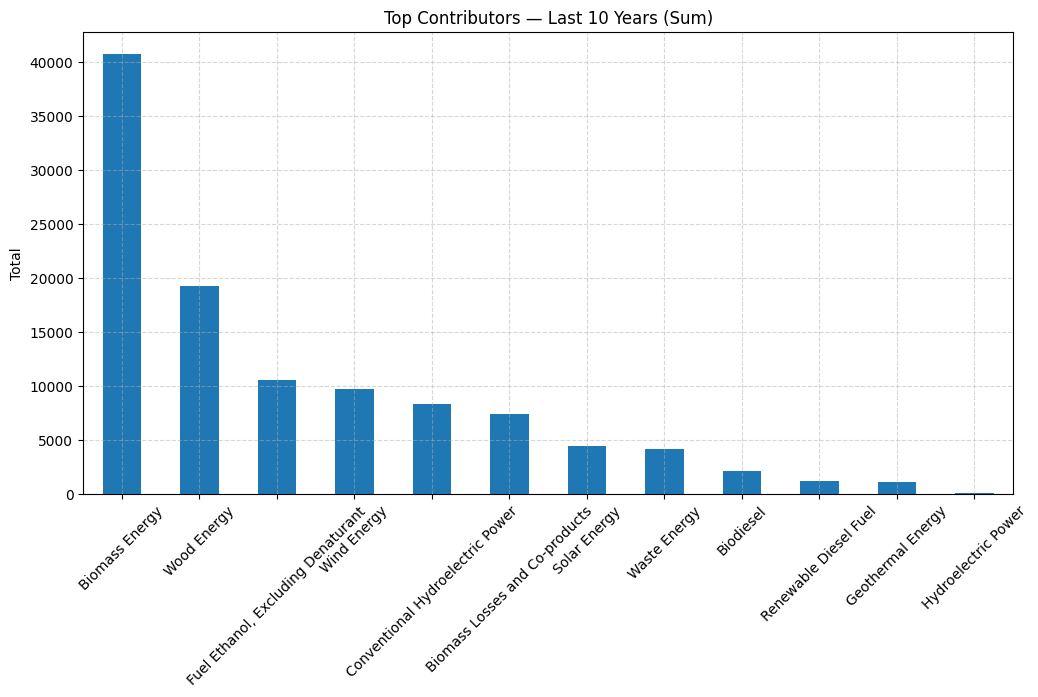

CAGR % from 2015 to 2024:


Renewable Diesel Fuel                 -4.890
Solar Energy                         -13.560
Wind Energy                          -17.180
Biodiesel                            -22.220
Biomass Losses and Co-products       -23.890
Conventional Hydroelectric Power     -23.930
Geothermal Energy                    -23.930
Biomass Energy                       -24.170
Fuel Ethanol, Excluding Denaturant   -24.670
Hydroelectric Power                  -24.750
Wood Energy                          -25.620
Waste Energy                         -26.050
dtype: float64

In [6]:

# Peak & trough years per major source
peaks = {}
troughs = {}
for col in major_sources:
    s = yearly_sources[['Year', col]].dropna()
    y_max = s.loc[s[col].idxmax(), 'Year']
    y_min = s.loc[s[col].idxmin(), 'Year']
    peaks[col] = int(y_max)
    troughs[col] = int(y_min)

print("Peak year per source:", peaks)
print("Trough year per source:", troughs)

# Top contributors in the last 10 years
last_10 = sorted(df['Year'].unique())[-10:]
last10_sum = df[df['Year'].isin(last_10)][major_sources].sum().sort_values(ascending=False)

plt.figure()
last10_sum.plot(kind='bar')
plt.title("Top Contributors — Last 10 Years (Sum)")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# CAGR over last 10 years for selected sources (where possible)
yr_min, yr_max = min(last_10), max(last_10)
yr_src = yearly_sources.set_index('Year').loc[[yr_min, yr_max]]
cagr = (yr_src.loc[yr_max] / yr_src.loc[yr_min])**(1/(yr_max-yr_min)) - 1
cagr = (cagr * 100).sort_values(ascending=False)
print(f"CAGR % from {yr_min} to {yr_max}:")
display(cagr.round(2))


## 4. Forecasting (to 2040)


We fit a simple **SARIMAX(1,1,1)** with automatic seasonal period detection (if monthly data present) for a few key sources and Total.  
This is illustrative — for production-quality forecasts, tune (p,d,q)(P,D,Q)m via AIC/BIC grid search.


ADF p-value (Total): 0.9185


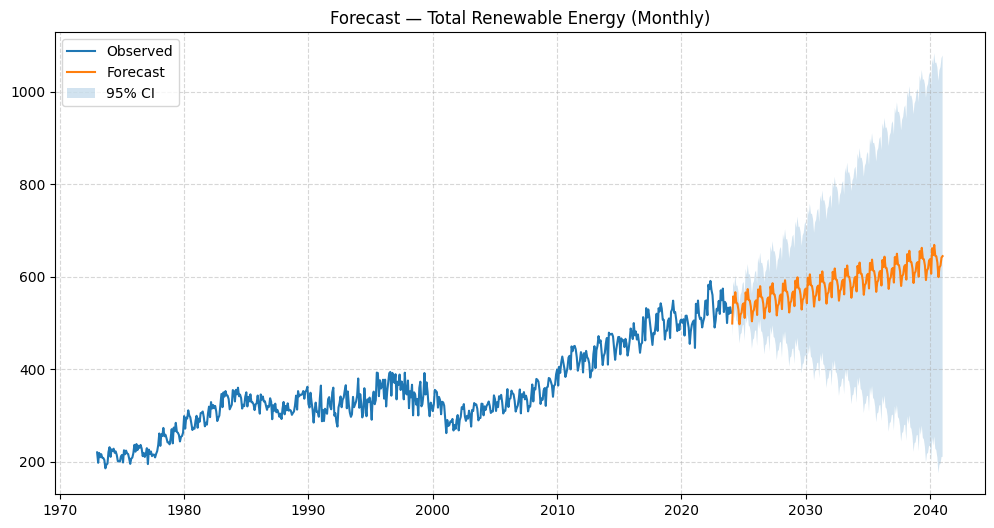

Skipping Solar Energy: no data to fit.
Skipping Wind Energy: no data to fit.
Skipping Conventional Hydroelectric Power: no data to fit.


C:\Users\saadf\AppData\Local\Temp\ipykernel_16256\651166448.py:35: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts = yearly_targets[col].asfreq('Y')


In [9]:

def fit_sarimax(ts, order=(1,1,1), seasonal_order=(0,0,0,0)):
    model = SARIMAX(ts, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    return res

# Build a monthly total time series if Date exists
if 'Date' in df.columns:
    monthly_total = df.groupby('Date')['Total Renewable Energy'].sum().asfreq('MS')
    # Quick stationarity check
    adf_stat, pval, *_ = adfuller(monthly_total.dropna())
    print(f"ADF p-value (Total): {pval:0.4f}")

    # Use simple SARIMA with yearly seasonality m=12
    res_total = fit_sarimax(monthly_total, order=(1,1,1), seasonal_order=(1,1,1,12))
    forecast_total = res_total.get_forecast(steps=12*max(0, 2040 - monthly_total.index[-1].year + 1))
    fc_mean = forecast_total.predicted_mean
    fc_ci = forecast_total.conf_int()

    plt.figure()
    plt.plot(monthly_total.index, monthly_total.values, label='Observed')
    plt.plot(fc_mean.index, fc_mean.values, label='Forecast')
    plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.2, label='95% CI')
    plt.title("Forecast — Total Renewable Energy (Monthly)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Forecast a couple of key sources yearly (aggregate first)
targets = ['Solar Energy','Wind Energy','Conventional Hydroelectric Power']
yearly_targets = df.groupby('Year')[targets].sum()

res_models = {}
fc_years = list(range(int(yearly_targets.index.max())+1, 2041))
for col in targets:
    ts = yearly_targets[col].asfreq('Y')
    # Skip if the series is empty or all NaN/zero
    if ts.dropna().empty or (ts.dropna() == 0).all():
        print(f"Skipping {col}: no data to fit.")
        continue
    # No seasonality for yearly data (m=0)
    res = fit_sarimax(ts, order=(1,1,1), seasonal_order=(0,0,0,0))
    res_models[col] = res
    fc = res.get_forecast(steps=len(fc_years))
    fc_mean = fc.predicted_mean
    plt.figure()
    plt.plot(ts.index.year, ts.values, marker='o', label='Observed')
    plt.plot(fc_mean.index.year, fc_mean.values, marker='o', label='Forecast')
    plt.title(f"Forecast — {col} (Yearly)")
    plt.xlabel("Year")
    plt.ylabel("Total")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


## 5. Conclusions


**Key takeaways (fill after running):**
- Which sectors contribute most on average and in total.
- Fastest-growing sources (CAGR) over the last decade.
- Peak/trough years for each major source.
- Forecast direction to 2040 (rising/flattening) with uncertainty bands.

**Next steps:**
- Hyperparameter tuning for SARIMA orders per series via AIC grid search.
- Consider exogenous drivers (e.g., policy, price indices) with SARIMAX exog.
- Build a dashboard (Plotly) for interactive exploration.
